In [ ]:
### DrugMechDB: A Comprehensive Curated Database of  Drug Mechanisms

Notebook to recreate figures of DrugMechDB manuscript

In [2]:
import sys
from pathlib import Path

In [102]:
# !pip install -r requirements.txt

import pandas as pd
import networkx as nx
import re
import yaml
from itertools import chain
from pathlib import Path
from operator import itemgetter
from collections import defaultdict
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# !pip install mygene
import mygene
mg = mygene.MyGeneInfo()

# 


In [6]:
os.getcwd()

'/home/jjoy/projects/DrugMechDB'

In [5]:
os.chdir("/home/jjoy/projects/DrugMechDB/")

In [64]:
os.getcwd()

'/home/jjoy/projects/DrugMechDB'

In [7]:
import sys
print(sys.path)

['/home/jjoy/miniforge3/envs/dmdb/lib/python313.zip', '/home/jjoy/miniforge3/envs/dmdb/lib/python3.13', '/home/jjoy/miniforge3/envs/dmdb/lib/python3.13/lib-dynload', '', '/home/jjoy/miniforge3/envs/dmdb/lib/python3.13/site-packages']


In [8]:
sys.path.append('/home/jjoy/projects/DrugMechDB')

In [58]:
print(sys.path)

['/home/jjoy/miniforge3/envs/dmdb/lib/python313.zip', '/home/jjoy/miniforge3/envs/dmdb/lib/python3.13', '/home/jjoy/miniforge3/envs/dmdb/lib/python3.13/lib-dynload', '', '/home/jjoy/miniforge3/envs/dmdb/lib/python3.13/site-packages', '/home/jjoy/projects/DrugMechDB']


In [81]:
print("\n".join(sys.path))

/home/jjoy/miniforge3/envs/dmdb/lib/python313.zip
/home/jjoy/miniforge3/envs/dmdb/lib/python3.13
/home/jjoy/miniforge3/envs/dmdb/lib/python3.13/lib-dynload

/home/jjoy/miniforge3/envs/dmdb/lib/python3.13/site-packages
/home/jjoy/projects/DrugMechDB


In [48]:
sys.path.remove("/home/jjoy/projects/DrugMechDB/")

In [66]:
import data_tools
print(data_tools.__file__)


/home/jjoy/miniforge3/envs/dmdb/lib/python3.13/site-packages/data_tools/__init__.py


In [9]:
os.getcwd()

'/home/jjoy/projects/DrugMechDB'

In [10]:
from data_tools.data_tools.files._retrieval import download
from data_tools.data_tools.files._analysis import *

In [11]:
from data_tools.data_tools.plotting import count_plot_h,venn2_pretty, venn3_pretty
#  from data_tools.data_tools.plotting import count_plot_h, venn2_pretty, venn3_pretty

In [12]:
#import libraries 

from pySankey.sankey import sankey
from tqdm import tqdm

from wordcloud import WordCloud, STOPWORDS

import warnings
warnings.filterwarnings("ignore")

In [13]:
# Make the output folders
this_name = '1_basic_dmdb_analysis'
out_dir = Path('../2_pipeline').joinpath(this_name, 'out').resolve()
out_dir.mkdir(parents=True, exist_ok=True)

data_dir = Path('../0_data/external').resolve()
data_dir.mkdir(parents=True, exist_ok=True)

In [14]:
DMDB_URL = 'https://raw.githubusercontent.com/SuLab/DrugMechDB/main/indication_paths.yaml'
download(DMDB_URL, data_dir.joinpath('indication_paths.yaml'), redownload=False)

File indication_paths.yaml exits. Skipping...


In [15]:
with open(data_dir.joinpath('indication_paths.yaml'), 'r') as fh:
        ind = yaml.safe_load(fh)

In [16]:
all_metapath_nodes = get_metapath_node(ind)
all_metapath_edges = get_metapath_edges(ind)

In [17]:
basic_stats = defaultdict(list)
all_metaedges = []
all_parings = []
all_targets = []
unique_metaedges = []
first_edge_type = []
all_nodes = []

id_to_name = {}
id_to_label = {}

for i, p in enumerate(ind):
    _id = (p["graph"]["_id"])
    drug_id, dis_id = path_to_tup(p)
    paths = get_all_paths(p)
    G = path_to_G(p)
    
    G = add_metaedges(G)
    G = add_meanode_pairs(G)
    
    basic_stats['idx'].append(i) #index
    basic_stats['id'].append(p['graph']['_id']) #DrugMechDB id
    basic_stats['drug'].append(drug_id) #Drug id
    basic_stats['disease'].append(dis_id)#Disease id
    basic_stats['nodes'].append((G.nodes)) #nodes in metapath
    basic_stats['n_nodes'].append(len(G.nodes)) # number of nodes in metapath
    basic_stats['n_edges'].append(len(G.edges)) #number of edges in metapath
    basic_stats['n_paths'].append(len(all_metapath_nodes[_id])) #number of paths
    basic_stats['metapath'].append(all_metapath_nodes[_id])
    basic_stats['metapath_with_edges'].append(all_metapath_edges[_id])

    
    this_metaedges = [G.edges[e]['metaedge'] for e in G.edges]
    
    all_metaedges += this_metaedges
    unique_metaedges += list(set(this_metaedges))
    
    all_parings += [G.edges[e]['mn_pair'] for e in G.edges]
    all_targets += get_targets(G)
    first_edge_type += get_target_metaedges(G)
    all_nodes += list(G.nodes)
    
    id_to_label = {**id_to_label, **get_id_to_type(G)}
    id_to_name = {**id_to_name, **get_id_to_name(G)}
    
basic_stats = pd.DataFrame(basic_stats)

In [18]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [19]:
basic_stats.head()

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
1,1,DB00619_MESH_D034721_1,DB:DB00619,MESH:D034721,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease]
2,2,DB00316_MESH_D010146_1,DB:DB00316,MESH:D010146,"(MESH:D000082, UniProt:P23219, UniProt:P35354, UniProt:Q15185, GO:0001516, MESH:D011453, MESH:D010146)",7,8,1,[Drug - Protein - BiologicalProcess - ChemicalSubstance - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - increases abundance of - ChemicalSubstance - positively correlated with - Disease]
3,3,DB00316_MESH_D005334_1,DB:DB00316,MESH:D005334,"(MESH:D000082, reactome:R-HSA-2162123, UBERON:0000955, GO:0001659, MESH:D005334)",5,4,1,[Drug - Pathway - GrossAnatomicalStructure - BiologicalProcess - Disease],[Drug - negatively regulates - Pathway - occurs in - GrossAnatomicalStructure - location of - BiologicalProcess - negatively correlated with - Disease]
4,4,DB00945_MESH_D010146_1,DB:DB00945,MESH:D010146,"(MESH:D001241, UniProt:P23219, UniProt:P35354, GO:0001516, MESH:D011453, GO:0006954, MESH:D010146)",7,7,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease]


In [20]:
basic_stats["metapath_with_edges"].apply(lambda x: tuple(x) if isinstance(x, list) else x).nunique()

1331

In [17]:
basic_stats["metapath_with_edges"].apply(lambda x: tuple(x) if isinstance(x, list) else x).unique()

array([('Drug - decreases activity of - Protein - causes - Disease',),
       ('Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease',),
       ('Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - increases abundance of - ChemicalSubstance - positively correlated with - Disease',),
       ...,
       ('Drug - positively regulates - Protein - increases abundance of - GeneFamily - positively correlated with - BiologicalProcess - positively correlated with - PhenotypicFeature - manifestation of - Disease',),
       ('Drug - positively regulates - Protein - increases abundance of - GeneFamily - positively correlated with - BiologicalProcess - caused by - OrganismTaxon - causes - Disease',),
       ('Drug - positively regulates - Protein - negatively correlated with - BiologicalProcess - positively correlated with - Disease',)],
      dtype=object)

In [ ]:
basic_stats["metapath_with_edges"].apply(
    lambda x: isinstance(x, list) and len(x) > 1 and x[0].startswith("Drug") and x[-1].startswith("Disease")
).sum()

np.int64(0)

In [21]:
basic_stats = pd.DataFrame(basic_stats)

In [22]:
basic_stats.shape

(4846, 10)

In [25]:
def contains_target_string(metapath_with_edges_list, target_string):
    return target_string in metapath_with_edges_list

target_string = "Drug - decreases activity of - Protein - causes - Disease"

filtered_df = basic_stats[basic_stats['metapath_with_edges'].apply(lambda x: contains_target_string(x, target_string))]


In [26]:
filtered_df.shape

(3, 10)

In [27]:
filtered_df

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
241,241,DB04865_MESH_D015464_1,DB:DB04865,MESH:D015464,"(MESH:C001652, UniProt:P39023, GO:0006412, UniProt:A9UF02, MESH:D015464)",5,4,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
435,435,DB06616_MESH_D001752_1,DB:DB06616,MESH:D001752,"(MESH:C471992, UniProt:A9UF02, MESH:D001752)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


In [274]:
basic_stats[(basic_stats["n_nodes"]==3) & (basic_stats["n_edges"]==2) & (basic_stats["n_paths"]==1)].head(5)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
23,23,DB00326_MESH_D006996_1,DB:DB00326,MESH:D006996,"(MESH:C007852, MESH:D002118, MESH:D006996)",3,2,1,[Drug - ChemicalSubstance - Disease],[Drug - increases abundance of - ChemicalSubstance - prevents - Disease]
43,43,DB00650_MESH_D000749_1,DB:DB00650,MESH:D000749,"(MESH:D002955, MESH:D005492, MESH:D000749)",3,2,1,[Drug - ChemicalSubstance - Disease],[Drug - increases abundance of - ChemicalSubstance - prevents - Disease]
50,50,MESH_C106301_MESH_D003233_1,None,MESH:D003233,"(MESH:C106301, GO:0002553, MESH:D003233)",3,2,1,[Drug - BiologicalProcess - Disease],[Drug - negatively regulates - BiologicalProcess - correlated with - Disease]
58,58,DB06786_MESH_D012871_1,DB:DB06786,MESH:D012871,"(MESH:D006206, GO:0006954, MESH:D012871)",3,2,1,[Drug - BiologicalProcess - Disease],[Drug - negatively regulates - BiologicalProcess - causes - Disease]


In [281]:
basic_stats["n_paths"].value_counts()

n_paths
1     4258
2      440
4       48
3       41
0       29
5       15
6       13
21       1
10       1
Name: count, dtype: int64

In [285]:
type(basic_stats)

pandas.core.frame.DataFrame

In [287]:
print(basic_stats[["drug", "disease", "nodes"]].isna().sum())  # Check for NaNs
print(basic_stats[["drug", "disease", "nodes"]].head())  

drug       1
disease    0
nodes      0
dtype: int64
         drug       disease  \
0  DB:DB00619  MESH:D015464   
1  DB:DB00619  MESH:D034721   
2  DB:DB00316  MESH:D010146   
3  DB:DB00316  MESH:D005334   
4  DB:DB00945  MESH:D010146   

                                                                                                    nodes  
0                                                         (MESH:D000068877, UniProt:P00519, MESH:D015464)  
1                             (MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)  
2  (MESH:D000082, UniProt:P23219, UniProt:P35354, UniProt:Q15185, GO:0001516, MESH:D011453, MESH:D010146)  
3                        (MESH:D000082, reactome:R-HSA-2162123, UBERON:0000955, GO:0001659, MESH:D005334)  
4      (MESH:D001241, UniProt:P23219, UniProt:P35354, GO:0001516, MESH:D011453, GO:0006954, MESH:D010146)  


In [289]:
basic_stats[basic_stats["drug"].isna()]


,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
50,50,MESH_C106301_MESH_D003233_1,None,MESH:D003233,"(MESH:C106301, GO:0002553, MESH:D003233)",3,2,1,[Drug - BiologicalProcess - Disease],[Drug - negatively regulates - BiologicalProcess - correlated with - Disease]


In [291]:
basic_stats["drug"] = basic_stats["drug"].fillna("Unknown")

In [292]:
basic_stats[basic_stats["drug"].isna()]

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges


In [296]:
grouped = basic_stats.groupby(["drug", "disease"])
grouped_agg = grouped.size().reset_index(name="count")  # Example aggregation
print(grouped_agg.shape)

(4648, 3)


In [300]:
grouped_agg[grouped_agg["count"]>1].head(3)

,drug,disease,count
13,DB:DB00008,MESH:D019698,2
36,DB:DB00038,MESH:D013921,2
153,DB:DB00169,MESH:D014808,2


In [23]:
basic_stats["n_paths"].value_counts()

n_paths
1     4258
2      440
4       48
3       41
0       29
5       15
6       13
21       1
10       1
Name: count, dtype: int64

In [54]:
import ast

In [23]:
basic_stats[basic_stats["id"]=="DB00674_MESH_D000544_1"]

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
2805,2805,DB00674_MESH_D000544_1,DB:DB00674,MESH:D000544,"(MESH:D005702, UniProt:P22303, GO:0006581, CHEBI:15355, HP:0100543, MESH:D000544)",6,5,1,[Drug - Protein - BiologicalProcess - ChemicalSubstance - PhenotypicFeature - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - decreases abundance of - ChemicalSubstance - negatively correlated with - PhenotypicFeature - manifestation of - Disease]


# Benchmark Creation

### Drug- Biological Process dataset creation

Which biological process is altered by amoxicillin in the treatment of Streptococcal tonsillitis?

Which Drug can be used in the treatment of Bacterial septicemia by targeting bacterial Nucleic Acid synthesis?

In [52]:
def count_go_occurrences(nodes_set):
    # Count how many times 'GO' appears in the nodes and filter for them
    return sum(1 for node in nodes_set if 'GO:' in node)

# Filter DataFrame
go_bp = basic_stats[basic_stats['nodes'].apply(count_go_occurrences)==1]

go_bp.shape

(1840, 10)

In [25]:
go_bp.iloc[0:1]

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
1,1,DB00619_MESH_D034721_1,DB:DB00619,MESH:D034721,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease]


In [27]:
def extract_go_ids(nodes):
    return ', '.join([node for node in nodes if node.startswith('GO:')])

go_bp['bp'] = go_bp['nodes'].apply(extract_go_ids)

In [28]:
go_bp['Drug_MeshID'] = go_bp['nodes'].apply(lambda x: list(x)[0])

In [31]:
go_bp.iloc[0:1]

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,bp,Drug_MeshID
1,1,DB00619_MESH_D034721_1,DB:DB00619,MESH:D034721,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease],GO:0008283,MESH:D000068877


In [32]:
def get_names(row, id_to_name):
    drug_name = id_to_name.get(row['Drug_MeshID'], 'Unknown')
    disease_name = id_to_name.get(row['disease'], 'Unknown')
    
    # Handle multiple protein IDs
    bp_ids = row['bp'].split(', ') if isinstance(row['bp'], str) else [row['bp']]
    bp_names = [id_to_name.get(bp_id, 'Unknown') for bp_id in bp_ids]

    return pd.Series([drug_name, disease_name, bp_names])


In [33]:
def map_node_names_from_nodeview(node_view, id_to_name):
    if not hasattr(node_view, '__iter__'):
        return ['Unknown']
    
    return [id_to_name.get(str(node_id).strip(), 'Unknown') for node_id in node_view]


In [34]:
go_bp['node_names'] = go_bp['nodes'].apply(lambda x: map_node_names_from_nodeview(x, id_to_name))


In [35]:
go_bp.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,bp,Drug_MeshID,node_names
1,1,DB00619_MESH_D034721_1,DB:DB00619,MESH:D034721,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease],GO:0008283,MESH:D000068877,"[imatinib, Mast/stem cell growth factor receptor Kit, Platelet-derived growth factor receptor alpha, cell population proliferation, Systemic mast cell disease]"


In [36]:
go_bp[['drug_name', 'disease_name', 'bp_name']] = go_bp.apply(get_names, axis=1, id_to_name=id_to_name)

In [37]:
go_bp.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,bp,Drug_MeshID,node_names,drug_name,disease_name,bp_name
1,1,DB00619_MESH_D034721_1,DB:DB00619,MESH:D034721,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease],GO:0008283,MESH:D000068877,"[imatinib, Mast/stem cell growth factor receptor Kit, Platelet-derived growth factor receptor alpha, cell population proliferation, Systemic mast cell disease]",imatinib,Systemic mast cell disease,[cell population proliferation]


In [38]:
# convert bp_name into str
go_bp['bp_name'] = go_bp['bp_name'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

In [39]:
go_bp.shape

(1840, 16)

In [40]:

go_bp['question'] = "Which Drug can be used in the treatment of " + go_bp['disease_name'] + " by targeting biological process: " + go_bp['bp_name'] + "?"

In [41]:
go_bp.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,bp,Drug_MeshID,node_names,drug_name,disease_name,bp_name,question
1,1,DB00619_MESH_D034721_1,DB:DB00619,MESH:D034721,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease],GO:0008283,MESH:D000068877,"[imatinib, Mast/stem cell growth factor receptor Kit, Platelet-derived growth factor receptor alpha, cell population proliferation, Systemic mast cell disease]",imatinib,Systemic mast cell disease,cell population proliferation,Which Drug can be used in the treatment of Systemic mast cell disease by targeting biological process: cell population proliferation?


In [42]:
go_bp["n_nodes"].value_counts()

n_nodes
5     655
6     496
7     231
4     171
8     136
9      47
3      41
10     36
11     16
13      5
12      4
14      2
Name: count, dtype: int64

#### for the drug-centric benchmark, for now will take nodes greaster than 2 and less than 6 to capture mechanistic relationships without them getting too complex with increasing the number of intermediate nodes

In [43]:
go_bp["n_paths"].value_counts()

n_paths
1    1704
2     116
5       8
0       6
3       4
4       2
Name: count, dtype: int64

In [44]:
go_bp["Drug_MeshID"] = go_bp["Drug_MeshID"].str.replace(
    r"^DB:", "DRUGBANK:", regex=True
)

In [45]:
go_bp["drug"] = go_bp["drug"].str.replace(
    r"^DB:", "DRUGBANK:", regex=True
)

In [46]:
# filter go_bp with n_paths == 1 and n_nodes >2 and n_nodes < 6
go_bp_filtered = go_bp[(go_bp["n_paths"] == 1) & (go_bp["n_nodes"] > 2) & (go_bp["n_nodes"] < 6)]
go_bp_filtered.shape

(842, 17)

In [47]:
columns_order = ['idx', 'id', 'drug', 'Drug_MeshID', 'disease', 'bp','drug_name','disease_name','bp_name','nodes', 'n_nodes', 'n_edges', 'n_paths', 'metapath', 'metapath_with_edges', 'question']
go_bp_filtered = go_bp_filtered[columns_order]

In [48]:
go_bp_filtered.head(1)

,idx,id,drug,Drug_MeshID,disease,bp,drug_name,disease_name,bp_name,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,question
1,1,DB00619_MESH_D034721_1,DRUGBANK:DB00619,MESH:D000068877,MESH:D034721,GO:0008283,imatinib,Systemic mast cell disease,cell population proliferation,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease],Which Drug can be used in the treatment of Systemic mast cell disease by targeting biological process: cell population proliferation?


In [49]:
go_bp_filtered.shape

(842, 16)

In [ ]:
# go_bp_filtered.to_csv("_data/DMDB_go_bp_filtered.csv", index=False)

### Metabolite dataset

In [51]:
def count_chebi_occurrences(nodes_set):
    # Count how many times 'CEHBI' appears in the nodes 
    return sum(1 for node in nodes_set if 'CHEBI:' in node)

# Filter DataFrame
chebi_metabolite = basic_stats[basic_stats['nodes'].apply(count_chebi_occurrences)==1]

chebi_metabolite.shape

(327, 10)

In [257]:
chebi_metabolite.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
56,56,DB00994_MESH_D007634_1,DB:DB00994,MESH:D007634,"(MESH:D009355, CHEBI:18111, GO:0006412, taxonomy:1280, MESH:D007634)",5,4,1,[Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease]


In [53]:
def extract_chebi_ids(nodes):
    return ', '.join([node for node in nodes if node.startswith('CHEBI:')])

chebi_metabolite['metabolite'] = chebi_metabolite['nodes'].apply(extract_chebi_ids)

In [54]:
chebi_metabolite.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,metabolite
56,56,DB00994_MESH_D007634_1,DB:DB00994,MESH:D007634,"(MESH:D009355, CHEBI:18111, GO:0006412, taxonomy:1280, MESH:D007634)",5,4,1,[Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease],CHEBI:18111


In [55]:
chebi_metabolite['Drug_MeshID'] = chebi_metabolite['nodes'].apply(lambda x: list(x)[0])

In [56]:
def get_names(row, id_to_name):
    drug_name = id_to_name.get(row['Drug_MeshID'], 'Unknown')
    disease_name = id_to_name.get(row['disease'], 'Unknown')
    
    # Handle multiple protein IDs
    metabolite_ids = row['metabolite'].split(', ') if isinstance(row['metabolite'], str) else [row['metabolite']]
    metabolite_names = [id_to_name.get(metabolite_id, 'Unknown') for metabolite_id in metabolite_ids]

    return pd.Series([drug_name, disease_name, metabolite_names])


In [57]:
id_to_name.get("CHEBI:18111")

'ribosomal RNA'

In [58]:
print(repr(chebi_metabolite['nodes'].iloc[0]))


NodeView(('MESH:D009355', 'CHEBI:18111', 'GO:0006412', 'taxonomy:1280', 'MESH:D007634'))


In [59]:
def map_node_names_from_nodeview(node_view, id_to_name):
    if not hasattr(node_view, '__iter__'):
        return ['Unknown']
    
    return [id_to_name.get(str(node_id).strip(), 'Unknown') for node_id in node_view]


In [60]:
chebi_metabolite['node_names'] = chebi_metabolite['nodes'].apply(lambda x: map_node_names_from_nodeview(x, id_to_name))


In [61]:
chebi_metabolite.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,metabolite,Drug_MeshID,node_names
56,56,DB00994_MESH_D007634_1,DB:DB00994,MESH:D007634,"(MESH:D009355, CHEBI:18111, GO:0006412, taxonomy:1280, MESH:D007634)",5,4,1,[Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease],CHEBI:18111,MESH:D009355,"[neomycin, ribosomal RNA, translation, Staphylococcus aureus, Keratitis]"


In [62]:
# Check if 'ChemicalSubstance' is present in each row
has_chemical = chebi_metabolite['metapath_with_edges'].apply(lambda x: 'ChemicalSubstance' in str(x))

# Count how many rows have it and how many don't
count_with = has_chemical.sum()
count_without = (~has_chemical).sum()

print(f"Rows with 'ChemicalSubstance': {count_with}")
print(f"Rows without 'ChemicalSubstance': {count_without}")


Rows with 'ChemicalSubstance': 303
Rows without 'ChemicalSubstance': 24


In [63]:
chebi_metabolite[~chebi_metabolite['metapath_with_edges'].apply(lambda x: 'ChemicalSubstance' in str(x))].head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,metabolite,Drug_MeshID,node_names
542,542,DB00248_MESH_D006966_1,DB:DB00248,MESH:D006966,"(MESH:D000077465, UniProt:P14416, GO:0007195, CHEBI:17489, GO:0051209, GO:1902722, MESH:D006966)",7,6,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - increases activity of - Protein - participates in - BiologicalProcess - causes - Disease],CHEBI:17489,MESH:D000077465,"[Cabergoline, D(2) dopamine receptor, Adenylate cyclase-inhibiting dopamine receptor signaling pathway, 3',5'-cyclic AMP, Release of sequestered calcium ion into cytosol, Positive regulation of prolactin secretion, Hyperprolactinemia]"


In [64]:
chebi_metabolite[['drug_name', 'disease_name', 'metabolite_name']] = chebi_metabolite.apply(get_names, axis=1, id_to_name=id_to_name)

In [65]:
chebi_metabolite.shape

(327, 16)

In [66]:
chebi_metabolite["n_nodes"].value_counts()

n_nodes
7     83
5     55
8     48
6     34
4     21
10    18
11    18
9     18
3      9
13     8
12     7
14     5
15     2
18     1
Name: count, dtype: int64

In [67]:
def extract_edges(row):
    try:
        data = row['metapath_with_edges']
        
        # If it's a list with one string, flatten it
        if isinstance(data, list) and len(data) == 1 and isinstance(data[0], str):
            data = data[0]

        # If it's a string, parse it
        if isinstance(data, str):
            data = data.strip('[]')  # remove brackets
            elements = [x.strip() for x in data.split(' - ')]
        elif isinstance(data, list):
            elements = data  # already parsed
        else:
            return "Invalid format"
        
        # Edges are at odd indices
        edges = [elements[i] for i in range(1, len(elements), 2)]
        return edges
    except Exception as e:
        return f"Error: {e}"



In [68]:

chebi_metabolite['edges'] = chebi_metabolite.apply(extract_edges, axis=1)

In [76]:
def filter_and_format_metabolite_df(
    df,
    include_chemical_substance=True,
    exact_n_paths=1,
    columns_order=None
):
    
    df = df.copy()

    # Normalize DrugBank IDs
    df["Drug_MeshID"] = df["Drug_MeshID"].str.replace(r"^DB:", "DRUGBANK:", regex=True)
    df["drug"] = df["drug"].str.replace(r"^DB:", "DRUGBANK:", regex=True)

    # Filter by node count
    # df = df[(df["n_nodes"] >= min_nodes) & (df["n_nodes"] <= max_nodes)]

    # Exclude subclass metapaths
    df = df[~df["metapath_with_edges"].astype(str).str.contains("subclass")]

    # Include/exclude ChemicalSubstance
    if include_chemical_substance:
        df = df[df["metapath_with_edges"].astype(str).str.contains("ChemicalSubstance")]
    else:
        df = df[~df["metapath_with_edges"].astype(str).str.contains("ChemicalSubstance")]

    # Filter by exact path count
    if exact_n_paths is not None:
        df = df[df["n_paths"] == exact_n_paths]

    # Reorder columns if specified
    if columns_order:
        df = df[[col for col in columns_order if col in df.columns]]

    return df

In [74]:
chebi_metabolite.shape

(327, 17)

In [77]:
result_df = filter_and_format_metabolite_df(chebi_metabolite)
result_df.shape

(201, 17)

In [78]:
result_df["n_nodes"].value_counts()

n_nodes
7     63
5     44
8     28
6     27
4     18
9      9
3      6
10     2
12     1
11     1
14     1
13     1
Name: count, dtype: int64

In [79]:
#result_df.to_csv("_data/DMDB_chebi_metabolite_filtered_04_23_2025.csv", index=False)

In [81]:
result_df = pd.read_csv("_data/DMDB_chebi_metabolite_filtered_04_23_2025.csv")

In [82]:
result_df.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,metabolite,Drug_MeshID,node_names,drug_name,disease_name,metabolite_name,question,question_2,question_3,metabolite_name_str,random_mix_metabolites,question_1_mcq,question_2_mcq,question_3_mcq,edges
0,56,DB00994_MESH_D007634_1,DRUGBANK:DB00994,MESH:D007634,"['MESH:D009355', 'CHEBI:18111', 'GO:0006412', 'taxonomy:1280', 'MESH:D007634']",5,4,1,['Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease'],['Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease'],CHEBI:18111,MESH:D009355,"['neomycin', 'ribosomal RNA', 'translation', 'Staphylococcus aureus', 'Keratitis']",neomycin,Keratitis,['ribosomal RNA'],Which chemical substance (metabolite) is altered by neomycin in the treatment of Keratitis?,Which chemical substance is modulated by neomycin during the treatment of Keratitis?,Which chemical substance is affected by neomycin via its mechanism of action in Keratitis?,ribosomal RNA,"['glucose', 'bradykinin', 'low-density lipoprotein cholesterol']",Which chemical substance (metabolite) is altered by neomycin in the treatment of Keratitis?\nChoices: bradykinin; glucose; low-density lipoprotein cholesterol; ribosomal RNA,Which chemical substance is modulated by neomycin during the treatment of Keratitis?\nChoices: glucose; bradykinin; ribosomal RNA; low-density lipoprotein cholesterol,Which chemical substance is affected by neomycin via its mechanism of action in Keratitis?\nChoices: low-density lipoprotein cholesterol; ribosomal RNA; glucose; bradykinin,"['decreases activity of', 'participates in', 'in taxon', 'causes']"


### Gene-centric dataset

In [84]:
basic_stats.shape

(4846, 10)

In [85]:
basic_stats["uniprot_count"] = basic_stats["nodes"].apply(count_uniprot_occurrences)

In [86]:
basic_stats.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,uniprot_count
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease],1


In [87]:
basic_stats["uniprot_count"].value_counts()

uniprot_count
1     1802
0     1464
2      731
5      454
3      194
4      151
6       27
7       17
8        4
10       2
Name: count, dtype: int64

In [90]:
# unique metapth find in basic_stats[(basic_stats["uniprot_count"]==1) & (basic_stats["n_paths"]==1)]["metapath"]
#basic_stats[(basic_stats["uniprot_count"]==1) & (basic_stats["n_paths"]==1)]["metapath"].value_counts()

In [91]:
basic_stats[(basic_stats["uniprot_count"]==1) & (basic_stats["n_paths"]==1)][["id","metapath","metapath_with_edges","nodes","n_nodes",	"n_edges",	"n_paths","drug","disease"]].iloc[5:10]

,id,metapath,metapath_with_edges,nodes,n_nodes,n_edges,n_paths,drug,disease
19,DB08799_MESH_D012223_1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease],"(MESH:D000865, UniProt:P35367, GO:0034776, MESH:D012223)",4,3,1,DB:DB08799,MESH:D012223
20,DB01137_MESH_D011704_1,[Drug - Protein - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease],"(MESH:D064704, UniProt:P11388, GO:0006260, taxonomy:562, MESH:D011704)",5,4,1,DB:DB01137,MESH:D011704
21,DB00814_MESH_D010146_1,[Drug - Protein - ChemicalSubstance - GeneFamily - Disease],[Drug - decreases activity of - Protein - increases abundance of - ChemicalSubstance - increases activity of - GeneFamily - causes - Disease],"(MESH:D000077239, UniProt:P35354, MESH:D011453, InterPro:IPR000265, MESH:D010146)",5,4,1,DB:DB00814,MESH:D010146
26,DB00342_MESH_D017449_1,[Drug - Protein - PhenotypicFeature - Disease],[Drug - decreases activity of - Protein - has phenotype - PhenotypicFeature - manifestation of - Disease],"(MESH:D016593, UniProt:P35367, HP:0000969, MESH:D017449)",4,3,1,DB:DB00342,MESH:D017449
27,DB01048_MESH_D015658_1,[Drug - ChemicalSubstance - Protein - BiologicalProcess - Disease],[Drug - increases abundance of - ChemicalSubstance - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease],"(MESH:C106538, MESH:C066928, UniProt:P04585, GO:0039693, MESH:D015658)",5,4,1,DB:DB01048,MESH:D015658


In [92]:
def count_uniprot_occurrences(nodes_set):
    # Count how many times 'UniProt' appears in the nodes (which is a set in this case)
    return sum(1 for node in nodes_set if 'UniProt' in node)

# Filter DataFrame
filtered_df = basic_stats[basic_stats['nodes'].apply(count_uniprot_occurrences) == 1]

In [93]:
filtered_df.shape

(1802, 11)

In [322]:
# filtered_df.groupby(["drug", "disease"]).head(1)

In [94]:
filtered_df["n_paths"].value_counts()

n_paths
1     1523
2      200
4       27
0       18
3       15
5       11
6        7
10       1
Name: count, dtype: int64

In [514]:
filtered_df.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,uniprot_count
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease],1


In [95]:
def extract_uniprot_ids(nodes):
    return ', '.join([node for node in nodes if node.startswith('UniProt:')])

filtered_df['protein'] = filtered_df['nodes'].apply(extract_uniprot_ids)

In [96]:
columns_order = ['idx', 'id', 'drug', 'disease', 'protein', 'nodes', 'n_nodes', 'n_edges', 'n_paths', 'metapath', 'metapath_with_edges']
filtered_df = filtered_df[columns_order]
filtered_df['Drug_MeshID'] = filtered_df['nodes'].apply(lambda x: list(x)[0])
filtered_df.head(1)

,idx,id,drug,disease,protein,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,Drug_MeshID
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,UniProt:P00519,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease],MESH:D000068877


In [97]:
def get_names(row, id_to_name):
    drug_name = id_to_name.get(row['Drug_MeshID'], 'Unknown')
    disease_name = id_to_name.get(row['disease'], 'Unknown')
    protein_name = id_to_name.get(row['protein'], 'Unknown')
    
    return pd.Series([drug_name, disease_name, protein_name])

filtered_df[['drug_name', 'disease_name', 'protein_name']] = filtered_df.apply(get_names, axis=1, id_to_name=id_to_name)

In [104]:
filtered_df.head(1)

,idx,id,drug,disease,protein,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,Drug_MeshID,drug_name,disease_name,protein_name
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,UniProt:P00519,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease],MESH:D000068877,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1


In [105]:
def convert_protein_to_gene_symbol(uniprot_id):
    # Remove 'UniProt:' prefix
    uniprot_id = uniprot_id.replace('UniProt:', '')
    
    # Query mygene to get gene symbol
    gene_info = mg.query(uniprot_id, scopes='uniprot', fields='symbol', species='human')
    
    if gene_info and 'hits' in gene_info and gene_info['hits']:
        return gene_info['hits'][0].get('symbol', 'N/A')
    return 'N/A'

filtered_df['protein_gene_symbol'] = filtered_df['protein'].apply(convert_protein_to_gene_symbol)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

...

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

In [107]:
filtered_df.head(5)

,idx,id,drug,disease,protein,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,Drug_MeshID,drug_name,disease_name,protein_name,protein_gene_symbol
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,UniProt:P00519,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease],MESH:D000068877,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1,ABL1
5,5,DB00945_MESH_D013927_1,DB:DB00945,MESH:D013927,UniProt:P23219,"(MESH:D001241, UniProt:P23219, reactome:R-HSA-2162123, MESH:D013928, GO:0007596, MESH:D013927)",6,6,2,"[Drug - Protein - Pathway - ChemicalSubstance - BiologicalProcess - Disease, Drug - Protein - BiologicalProcess - Disease]","[Drug - decreases activity of - Protein - participates in - Pathway - has output - ChemicalSubstance - participates in - BiologicalProcess - causes - Disease, Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease]",MESH:D001241,Aspirin,Thrombosis,Prostaglandin G/H synthase 1,PTGS1
6,6,DB00788_MESH_D010146_1,DB:DB00788,MESH:D010146,UniProt:P35354,"(MESH:D009288, UniProt:P35354, MESH:D011453, GO:0006954, MESH:D010146)",5,4,1,[Drug - Protein - ChemicalSubstance - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - increases abundance of - ChemicalSubstance - participates in - BiologicalProcess - causes - Disease],MESH:D009288,naproxen,Pain,Prostaglandin G/H synthase 2,PTGS2
7,7,DB01059_MESH_D004405_1,DB:DB01059,MESH:D004405,UniProt:P43702,"(MESH:D009643, UniProt:P43702, GO:0003746, GO:0006260, GO:0006412, taxonomy:622, MESH:D004405)",7,7,2,"[Drug - Protein - BiologicalProcess - OrganismTaxon - Disease, Drug - MolecularActivity - BiologicalProcess - OrganismTaxon - Disease]","[Drug - decreases activity of - Protein - participates in - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease, Drug - negatively regulates - MolecularActivity - precedes - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease]",MESH:D009643,norfloxacin,"Dysentery, Bacillary",DNA topoisomerase 4 subunit A (Haemophilus influenzae),N/A
14,14,DB00479_MESH_D016920_1,DB:DB00479,MESH:D016920,UniProt:P0A7S3,"(MESH:D000583, UniProt:P0A7S3, GO:0006412, taxonomy:2, MESH:D016920)",5,4,1,[Drug - Protein - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease],MESH:D000583,amikacin,"Meningitis, Bacterial",30S ribosomal protein S12,N/A


In [108]:
filtered_df.shape

(1802, 16)

In [109]:
filtered_df = filtered_df[filtered_df["n_paths"]==1]

In [110]:
filtered_df[filtered_df['protein_gene_symbol'] == 'N/A'].shape

(256, 16)

In [113]:
filtered_df[filtered_df['protein_gene_symbol'] == 'N/A'].head(5)

,idx,id,drug,disease,protein,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,Drug_MeshID,drug_name,disease_name,protein_name,protein_gene_symbol
14,14,DB00479_MESH_D016920_1,DB:DB00479,MESH:D016920,UniProt:P0A7S3,"(MESH:D000583, UniProt:P0A7S3, GO:0006412, taxonomy:2, MESH:D016920)",5,4,1,[Drug - Protein - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease],MESH:D000583,amikacin,"Meningitis, Bacterial",30S ribosomal protein S12,N/A
18,18,DB01263_MESH_D009181_1,DB:DB01263,MESH:D009181,UniProt:P10613,"(MESH:C101425, UniProt:P10613, MESH:D004875, GO:0009277, MESH:D009181)",5,4,1,[Drug - Protein - ChemicalSubstance - CellularComponent - Disease],[Drug - decreases activity of - Protein - produces - ChemicalSubstance - located in - CellularComponent - correlated with - Disease],MESH:C101425,Posaconazole,Fungal Infection,Lanosterol 14-alpha-demethylase,N/A
27,27,DB01048_MESH_D015658_1,DB:DB01048,MESH:D015658,UniProt:P04585,"(MESH:C106538, MESH:C066928, UniProt:P04585, GO:0039693, MESH:D015658)",5,4,1,[Drug - ChemicalSubstance - Protein - BiologicalProcess - Disease],[Drug - increases abundance of - ChemicalSubstance - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease],MESH:C106538,abacavir,Human immunodeficiency virus infection,Gag-Pol polyprotein,N/A
32,32,DB01212_MESH_D006069_1,DB:DB01212,MESH:D006069,UniProt:P0A3M6,"(MESH:D002443, UniProt:P0A3M6, GO:0009252, taxonomy:485, MESH:D006069)",5,4,1,[Drug - Protein - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease],MESH:D002443,ceftriaxone,Gonorrhea,Penicillin-binding protein 2B,N/A
33,33,DB02703_MESH_D000881_1,DB:DB02703,MESH:D000881,UniProt:Q81VT3,"(MESH:D005672, UniProt:Q81VT3, GO:0006412, taxonomy:1392, MESH:D000881)",5,4,1,[Drug - Protein - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease],MESH:D005672,fusidic acid,Anthrax,Elongation factor G,N/A


In [523]:
filtered_df.columns

Index(['idx', 'id', 'drug', 'disease', 'protein', 'nodes', 'n_nodes',
       'n_edges', 'n_paths', 'metapath', 'metapath_with_edges', 'Drug_MeshID',
       'drug_name', 'disease_name', 'protein_name', 'protein_gene_symbol'],
      dtype='object')

In [114]:
columns_order = ['idx', 'id', 'drug', 'Drug_MeshID', 'disease', 'protein',	'drug_name','disease_name',	'protein_name','protein_gene_symbol','nodes', 'n_nodes', 'n_edges', 'n_paths', 'metapath', 'metapath_with_edges']
filtered_df = filtered_df[columns_order]

In [115]:
filtered_df["question"] = "Which gene plays the most significant mechanistic role in how Drug " + filtered_df["drug_name"] + " treats or impacts the Disease " + filtered_df["disease_name"] + "?"
filtered_df.head(1)

,idx,id,drug,Drug_MeshID,disease,protein,drug_name,disease_name,protein_name,protein_gene_symbol,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,question
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D000068877,MESH:D015464,UniProt:P00519,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1,ABL1,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease],Which gene plays the most significant mechanistic role in how Drug imatinib treats or impacts the Disease Chronic myeloid leukemia?


In [116]:
filtered_df[['id','drug', 'disease',  'drug_name', 'disease_name','protein', 'protein_name', 'protein_gene_symbol', 'question']].head(3)

,id,drug,disease,drug_name,disease_name,protein,protein_name,protein_gene_symbol,question
0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,imatinib,Chronic myeloid leukemia,UniProt:P00519,Tyrosine-protein kinase ABL1,ABL1,Which gene plays the most significant mechanistic role in how Drug imatinib treats or impacts the Disease Chronic myeloid leukemia?
6,DB00788_MESH_D010146_1,DB:DB00788,MESH:D010146,naproxen,Pain,UniProt:P35354,Prostaglandin G/H synthase 2,PTGS2,Which gene plays the most significant mechanistic role in how Drug naproxen treats or impacts the Disease Pain?
14,DB00479_MESH_D016920_1,DB:DB00479,MESH:D016920,amikacin,"Meningitis, Bacterial",UniProt:P0A7S3,30S ribosomal protein S12,N/A,"Which gene plays the most significant mechanistic role in how Drug amikacin treats or impacts the Disease Meningitis, Bacterial?"


In [117]:
ids_to_select = ["DB08799_MESH_D012223_1", "DB00342_MESH_D017449_1", "DB01048_MESH_D015658_1"]
# print rows in filtered_df where id is in ids_to_select
filtered_df[filtered_df["id"].isin(ids_to_select)]

,idx,id,drug,Drug_MeshID,disease,protein,drug_name,disease_name,protein_name,protein_gene_symbol,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,question
19,19,DB08799_MESH_D012223_1,DB:DB08799,MESH:D000865,MESH:D012223,UniProt:P35367,Antazoline,"Rhinitis, Vasomotor",Histamine H1 receptor,HRH1,"(MESH:D000865, UniProt:P35367, GO:0034776, MESH:D012223)",4,3,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease],"Which gene plays the most significant mechanistic role in how Drug Antazoline treats or impacts the Disease Rhinitis, Vasomotor?"
26,26,DB00342_MESH_D017449_1,DB:DB00342,MESH:D016593,MESH:D017449,UniProt:P35367,Terfenadine,allergic skin disorders,Histamine H1 receptor,HRH1,"(MESH:D016593, UniProt:P35367, HP:0000969, MESH:D017449)",4,3,1,[Drug - Protein - PhenotypicFeature - Disease],[Drug - decreases activity of - Protein - has phenotype - PhenotypicFeature - manifestation of - Disease],Which gene plays the most significant mechanistic role in how Drug Terfenadine treats or impacts the Disease allergic skin disorders?
27,27,DB01048_MESH_D015658_1,DB:DB01048,MESH:C106538,MESH:D015658,UniProt:P04585,abacavir,Human immunodeficiency virus infection,Gag-Pol polyprotein,N/A,"(MESH:C106538, MESH:C066928, UniProt:P04585, GO:0039693, MESH:D015658)",5,4,1,[Drug - ChemicalSubstance - Protein - BiologicalProcess - Disease],[Drug - increases abundance of - ChemicalSubstance - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease],Which gene plays the most significant mechanistic role in how Drug abacavir treats or impacts the Disease Human immunodeficiency virus infection?


In [118]:
filtered_df.shape

(1523, 17)

In [119]:
grouped_with_genes = (
    filtered_df.groupby(["disease", "Drug_MeshID"])
    .agg({
        "protein_gene_symbol": lambda x: ", ".join(set(x)),  # Concatenate unique symbols
        # Add any other columns to aggregate if needed
    })
    .reset_index()
)

# Add a count column to indicate the number of rows in each group
grouped_with_genes["count"] = filtered_df.groupby(["disease", "Drug_MeshID"]).size().values

In [352]:
filtered_df.head(1)

,idx,id,drug,Drug_MeshID,disease,protein,drug_name,disease_name,protein_name,protein_gene_symbol,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D000068877,MESH:D015464,UniProt:P00519,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1,ABL1,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


In [120]:
grouped_with_genes = (
    filtered_df.groupby(["disease", "Drug_MeshID"])
    .agg({
        "protein_gene_symbol": lambda x: ", ".join(set(x)),  # Concatenate unique symbols
        # "id": lambda x: ", ".join(set(x)),  # Keeping all unique IDs
        "drug": lambda x: ", ".join(set(x)),  # Keeping all unique drugs
        "drug_name": lambda x: ", ".join(set(x)),  # Keeping all unique drug names
        "disease_name": lambda x: ", ".join(set(x)),  # Keeping all unique disease names
        "protein_name": lambda x: ", ".join(set(x)),  # Keeping all unique protein names
        # "nodes": lambda x: ", ".join(set(x)),  # Keeping all unique nodes
        # "n_nodes": "first",  # Taking the first value assuming it's consistent
        # "n_edges": "first",  # Taking the first value assuming it's consistent
        # "n_paths": "first",  # Taking the first value assuming it's consistent
        # "metapath": lambda x: ", ".join(set(x)),  # Keeping all unique metapaths
        # "metapath_with_edges": lambda x: ", ".join(set(x))  # Keeping all unique metapaths with edges
    })
    .reset_index()
)

# Add a count column to indicate the number of unique proteins in each group
grouped_with_genes["count"] = filtered_df.groupby(["disease", "Drug_MeshID"])["protein"].nunique().values


In [121]:
grouped_with_genes["count"].value_counts()

count
1    1422
2      21
3       7
6       1
4       1
5       1
Name: count, dtype: int64

In [ ]:
# grouped_with_genes[grouped_with_genes["count"]>1]

In [122]:
filtered_df.shape

(1523, 17)

In [123]:
filtered_df[filtered_df["n_paths"]==1].shape

(1523, 17)

In [124]:
filtered_df = filtered_df[filtered_df["n_paths"]==1]

In [ ]:
# def count_uniprot_occurrences(protein_set):
#     # Count how many times 'UniProt' appears in the nodes (which is a set in this case)
#     return sum(1 for p in protein_set if 'Protein' in p)

# # Filter DataFrame
# filtered_df = basic_stats[basic_stats['metapath'].apply(count_uniprot_occurrences) == 1]

# filtered_df.shape #(3072, 10)

# filtered_df[filtered_df["n_paths"]==1].shape #(2865, 10)
# multiple Uniprot id's within it and it was not a single linear path


### Mechanistic genes - filtered data, n_paths =1 and only one protein


In [496]:
filtered_df.shape

(1523, 16)

In [125]:
filtered_df["n_nodes"].value_counts()

n_nodes
5     507
6     484
7     294
4     133
8      72
9      16
3      14
11      2
13      1
Name: count, dtype: int64

In [529]:
filtered_df.head(1)

,idx,id,drug,Drug_MeshID,disease,protein,drug_name,disease_name,protein_name,protein_gene_symbol,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D000068877,MESH:D015464,UniProt:P00519,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1,ABL1,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


In [530]:
# def extract_uniprot_ids(nodes):
#     return ', '.join([node for node in nodes if node.startswith('UniProt:')])

# filtered_df['protein'] = filtered_df['nodes'].apply(extract_uniprot_ids)

In [ ]:
# columns_order = ['idx', 'id', 'drug', 'disease', 'protein', 'nodes', 'n_nodes', 'n_edges', 'n_paths', 'metapath', 'metapath_with_edges']
# filtered_df = filtered_df[columns_order]

In [501]:
filtered_df.head(1)

,idx,id,drug,disease,protein,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,UniProt:P00519,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


In [ ]:
# create new column "Drug_MeshID" to get id names as DB numbers are not working
# filtered_df['Drug_MeshID'] = filtered_df['nodes'].apply(lambda x: list(x)[0])

In [473]:
filtered_df.head(2)

,idx,id,drug,Drug_MeshID,disease,protein,drug_name,disease_name,protein_name,protein_gene_symbol,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D000068877,MESH:D015464,UniProt:P00519,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1,ABL1,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
5,5,DB00945_MESH_D013927_1,DB:DB00945,MESH:D001241,MESH:D013927,UniProt:P23219,Aspirin,Thrombosis,Prostaglandin G/H synthase 1,PTGS1,"(MESH:D001241, UniProt:P23219, reactome:R-HSA-2162123, MESH:D013928, GO:0007596, MESH:D013927)",6,6,2,"[Drug - Protein - Pathway - ChemicalSubstance - BiologicalProcess - Disease, Drug - Protein - BiologicalProcess - Disease]","[Drug - decreases activity of - Protein - participates in - Pathway - has output - ChemicalSubstance - participates in - BiologicalProcess - causes - Disease, Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease]"


In [277]:
id_to_name["MESH:D015464"]

'Chronic myeloid leukemia'

In [126]:
def get_names(row, id_to_name):
    drug_name = id_to_name.get(row['Drug_MeshID'], 'Unknown')
    disease_name = id_to_name.get(row['disease'], 'Unknown')
    protein_name = id_to_name.get(row['protein'], 'Unknown')
    
    return pd.Series([drug_name, disease_name, protein_name])

In [217]:
id_to_name.keys()

dict_keys(['MESH:D000068877', 'UniProt:P00519', 'MESH:D015464', 'UniProt:P10721', 'UniProt:P16234', 'GO:0008283', 'MESH:D034721', 'MESH:D000082', 'UniProt:P23219', 'UniProt:P35354', 'UniProt:Q15185', 'GO:0001516', 'MESH:D011453', 'MESH:D010146', 'reactome:R-HSA-2162123', 'UBERON:0000955', 'GO:0001659', 'MESH:D005334', 'MESH:D001241', 'GO:0006954', 'MESH:D013928', 'GO:0007596', 'MESH:D013927', 'MESH:D009288', 'MESH:D009643', 'UniProt:P43702', 'GO:0003746', 'GO:0006260', 'GO:0006412', 'taxonomy:622', 'MESH:D004405', 'MESH:D003348', 'UniProt:P04150', 'UniProt:P04083', 'GO:0050900', 'MESH:D007634', 'MESH:D000077562', 'MESH:D015774', 'GO:0039693', 'taxonomy:10358', 'MESH:D003586', 'MESH:D008795', 'MESH:C029371', 'GO:0003676', 'taxonomy:2', 'MESH:D018805', 'MESH:D003707', 'UniProt:P0A7S3', 'UniProt:P0A7J3', 'taxonomy:786', 'MESH:D000073605', 'MESH:D000658', 'TIGR:02074', 'GO:0009252', 'taxonomy:1314', 'MESH:D014069', 'MESH:C106856', 'UniProt:P0C1U9', 'UniProt:P20831', 'taxonomy:1280', 'MESH:

In [219]:
id_to_name['MESH:D000068877']

'imatinib'

In [127]:
filtered_df[['drug_name', 'disease_name', 'protein_name']] = filtered_df.apply(get_names, axis=1, id_to_name=id_to_name)


In [128]:
columns_order = ['idx', 'id', 'drug', 'Drug_MeshID', 'disease', 'protein',	'drug_name','disease_name',	'protein_name','nodes', 'n_nodes', 'n_edges', 'n_paths', 'metapath', 'metapath_with_edges']
filtered_df = filtered_df[columns_order]

In [268]:
# make a new column "question" which conatins "what gene is is most mechanistically related to the indication of Drug X to Disease Y?" and use the drug_name for X and disease_name for Y 
filtered_df['question'] = "What gene is most mechanistically related to the indication of Drug " + filtered_df['drug_name'] + " to Disease " + filtered_df['disease_name'] + "?"

In [130]:
filtered_df.head(5)

,idx,id,drug,Drug_MeshID,disease,protein,drug_name,disease_name,protein_name,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D000068877,MESH:D015464,UniProt:P00519,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
6,6,DB00788_MESH_D010146_1,DB:DB00788,MESH:D009288,MESH:D010146,UniProt:P35354,naproxen,Pain,Prostaglandin G/H synthase 2,"(MESH:D009288, UniProt:P35354, MESH:D011453, GO:0006954, MESH:D010146)",5,4,1,[Drug - Protein - ChemicalSubstance - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - increases abundance of - ChemicalSubstance - participates in - BiologicalProcess - causes - Disease]
14,14,DB00479_MESH_D016920_1,DB:DB00479,MESH:D000583,MESH:D016920,UniProt:P0A7S3,amikacin,"Meningitis, Bacterial",30S ribosomal protein S12,"(MESH:D000583, UniProt:P0A7S3, GO:0006412, taxonomy:2, MESH:D016920)",5,4,1,[Drug - Protein - BiologicalProcess - OrganismTaxon - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease]
17,17,DB06762_MESH_D006973_1,DB:DB06762,MESH:D020110,MESH:D006973,UniProt:Q12791,pinacidil,Hypertension,Calcium-activated potassium channel subunit alpha-1,"(MESH:D020110, UniProt:Q12791, GO:0042311, GO:0008217, MESH:D006973)",5,4,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - increases activity of - Protein - participates in - BiologicalProcess - prevents - Disease]
18,18,DB01263_MESH_D009181_1,DB:DB01263,MESH:C101425,MESH:D009181,UniProt:P10613,Posaconazole,Fungal Infection,Lanosterol 14-alpha-demethylase,"(MESH:C101425, UniProt:P10613, MESH:D004875, GO:0009277, MESH:D009181)",5,4,1,[Drug - Protein - ChemicalSubstance - CellularComponent - Disease],[Drug - decreases activity of - Protein - produces - ChemicalSubstance - located in - CellularComponent - correlated with - Disease]


In [308]:
filtered_df.shape

(1523, 17)

In [253]:
import mygene
mg = mygene.MyGeneInfo()

In [254]:
mg = mygene.MyGeneInfo()

# List of NCBI Gene IDs
gene_ids = ['80336', '246329', '31111', '8835', '79602', '23030', '54997', '5413', '2185', '5742', '2995', '10678']

gene_info = mg.querymany(gene_ids, scopes='entrezgene', fields='symbol', species='human')

gene_name_dict = {item['query']: item.get('symbol', 'N/A') for item in gene_info}
df = pd.DataFrame(list(gene_name_dict.items()), columns=['NCBI Gene ID', 'Gene Name'])

print(df)

INFO:biothings.client:querying 1-12...
INFO:biothings.client:done.
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


   NCBI Gene ID Gene Name
0         80336   PABPC1L
1        246329     STAC3
2         31111       N/A
3          8835     SOCS2
4         79602   ADIPOR2
5         23030     KDM4B
6         54997      TESC
7          5413   SEPTIN5
8          2185     PTK2B
9          5742     PTGS1
10         2995      GYPC
11        10678    B3GNT2


In [255]:
uniprot_ids = ['P00519', 'P35354', 'P0A7S3', 'Q12791', 'P10613']

# Query mygene to get gene symbols
gene_info = mg.querymany(uniprot_ids, scopes='uniprot', fields='symbol', species='human')

gene_name_dict = {item['query']: item.get('symbol', 'N/A') for item in gene_info}
df = pd.DataFrame(list(gene_name_dict.items()), columns=['UniProt ID', 'Gene Symbol'])

print(df)

INFO:biothings.client:querying 1-5...
INFO:biothings.client:done.
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


  UniProt ID Gene Symbol
0     P00519        ABL1
1     P35354       PTGS2
2     P0A7S3         N/A
3     Q12791      KCNMA1
4     P10613         N/A


In [256]:
def convert_protein_to_gene_symbol(uniprot_id):
    # Remove 'UniProt:' prefix
    uniprot_id = uniprot_id.replace('UniProt:', '')
    
    # Query mygene to get gene symbol
    gene_info = mg.query(uniprot_id, scopes='uniprot', fields='symbol', species='human')
    
    if gene_info and 'hits' in gene_info and gene_info['hits']:
        return gene_info['hits'][0].get('symbol', 'N/A')
    return 'N/A'



In [257]:
# Apply the function to the 'protein' column and create new 'gene_name' column
filtered_df['protein_gene_symbol'] = filtered_df['protein'].apply(convert_protein_to_gene_symbol)

In [269]:
columns_order = ['idx', 'id', 'drug', 'Drug_MeshID', 'disease', 'protein',	'drug_name','disease_name',	'protein_name','protein_gene_symbol','nodes', 'n_nodes', 'n_edges', 'n_paths', 'metapath', 'metapath_with_edges', 'question']
filtered_df = filtered_df[columns_order]

In [476]:
filtered_df.head(1)

,idx,id,drug,Drug_MeshID,disease,protein,drug_name,disease_name,protein_name,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D000068877,MESH:D015464,UniProt:P00519,imatinib,Chronic myeloid leukemia,Tyrosine-protein kinase ABL1,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


In [271]:
filtered_df[filtered_df['protein_gene_symbol'] == 'N/A'].shape

(256, 17)

In [264]:
# find if there are any protein with more than one gene symbol
filtered_df['protein_gene_symbol'].value_counts()

protein_gene_symbol
N/A         256
HRH1        218
NR3C1       101
DRD2         37
SLC6A4       36
HRH2         32
ATP4A        29
AR           28
ADRB2        27
ADRA1A       26
CHRM3        24
HMGCR        21
PTGS2        20
TNF          19
VDR          19
OPRM1        17
VKORC1       15
ADRB1        15
SLC12A3      13
CHRM1        13
PGR          13
ESR1         12
SLC6A2       11
ADRA2A       11
PDE5A        10
ACHE         10
AGTR1         9
SLC12A1       9
DPP4          9
PTGIR         9
TUBB          8
ACE           7
GNRHR         7
CACNA1G       7
PDGFRA        7
PTGER2        6
ATP1A1        6
MS4A1         6
ABCC8         6
PTGFR         6
EGFR          6
SLC18A2       6
DPEP1         6
NR3C2         6
CACNA2D1      5
F10           5
CA2           5
MTOR          5
INSR          5
SLC5A2        5
TPO           5
P2RY12        5
ABL1          5
RRM1          5
CYP27B1       5
TOP2A         5
CACNA1E       4
ADRB3         4
CD274         4
S100P         4
TOP1          4
AVPR

In [272]:
# save the filtered_df
filtered_df.to_csv("_data/drugmechDB_mechanistic_genes_df.csv", index=False)



## Graph overview

In [159]:
basic_stats.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


In [74]:
#Count number of unique nodes
count_nodes_unique = set()
count_nodes = []
for indication in basic_stats["id"]: 
    nodes = list(basic_stats[basic_stats["id"] == indication]['nodes'].iloc[0])
    
    for n in nodes: 
        count_nodes_unique.add(n)
        count_nodes.append(n)

In [75]:
print("Number of nodes: ", len(count_nodes))
print("Number of unique nodes: ", len(count_nodes_unique))

Number of nodes:  32994
Number of unique nodes:  5128


In [76]:
print("Total edges: " , sum(basic_stats['n_edges'].to_list()) )

Total edges:  32597


In [77]:
print("Number of paths: " + str(sum(basic_stats['n_paths'])))

Number of paths: 5637


### Unique drugs/diseases/drug-disease combinations

In [78]:
print("Number of unique drugs: " + str(len(set(basic_stats['drug']))))
print("Number of unique diseases: " + str(len(set(basic_stats['disease']))))
print("Number of unique drug-disease combinations: " + str(len(basic_stats.groupby(['drug','disease']).size())))


Number of unique drugs: 1580
Number of unique diseases: 744
Number of unique drug-disease combinations: 4647


## Figure 2: DrugMechDB concept types

A) Top encountered node types

In [161]:
all_nodes[0:5] #list

['MESH:D000068877',
 'UniProt:P00519',
 'MESH:D015464',
 'MESH:D000068877',
 'UniProt:P10721']

In [79]:
node_counts = pd.Series(all_nodes, name='id')
node_counts = node_counts.to_frame().reset_index()
node_counts['label'] = node_counts['id'].map(id_to_label)

In [162]:
node_counts.head()

,index,id,label
0,0,MESH:D000068877,Drug
1,1,UniProt:P00519,Protein
2,2,MESH:D015464,Disease
3,3,MESH:D000068877,Drug
4,4,UniProt:P10721,Protein


In [165]:
# find if NA or "" in label, how many
node_counts[node_counts['label'].isna()].shape


(0, 3)

In [167]:
node_counts[node_counts['label']== ''].shape

(0, 3)

KeyError: ''

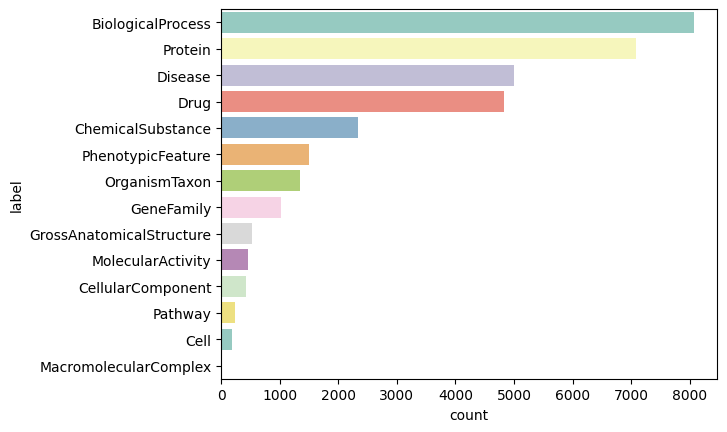

In [100]:
import matplotlib.pyplot as plt

# Ensure 'label' column exists in node_counts
if 'label' in node_counts.columns:
	plt.figure(dpi=100)
	count_plot_h(node_counts['label'].value_counts())
	plt.xlim(0,8800)
	plt.grid(linewidth=0.1)
	plt.title('Concept types in DrugMechDB')
	plt.xlabel('Number of times concept type encountered')
	plt.ylabel('Concept types')

	#plt.savefig('Concept types in DrugMechDB.pdf')

	# Change font style
	font = {'family': 'sans'}
	plt.rc('font', **font)
else:
	print("Error: 'label' column not found in node_counts DataFrame")

In [101]:
#Calcualte % of most common label 
total_label = len((node_counts["label"]))#Average of nodes per indication 
sum(list(basic_stats['n_nodes']))/len((basic_stats['n_nodes']))
biological_label = len(node_counts[node_counts["label"]=="BiologicalProcess"])
(biological_label*100)/total_label

24.455961690004244

In [102]:
#Calcualte % of second most common label 
total_label = len((node_counts["label"]))#Average of nodes per indication 
sum(list(basic_stats['n_nodes']))/len((basic_stats['n_nodes']))
biological_label = len(node_counts[node_counts["label"]=="Protein"])
(biological_label*100)/total_label

21.464508698551253

B) Distribution of nodes per indication

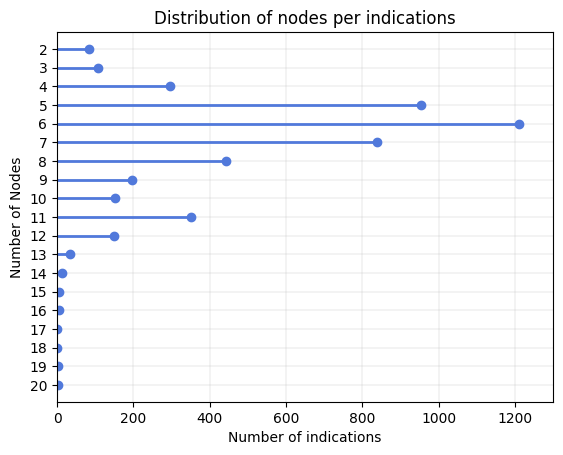

In [108]:
heads, locs = np.histogram(basic_stats['n_nodes'], bins=19)
plt.figure( dpi=100)
(markers, stemlines, baseline) =  plt.stem([str(i) for i in range(2,21)],
         heads, 
         basefmt = " ",
        orientation = "horizontal", )

plt.setp(stemlines, linestyle="-", color= '#5179DB', linewidth= 2 )
plt.setp(markers,  color='#5179DB')
plt.xlim([0,1300])

plt.grid(linewidth=0.2)
plt.gca().invert_yaxis()
plt.title('Distribution of nodes per indications')
plt.ylabel('Number of Nodes')
plt.xlabel('Number of indications');

#plt.savefig('Distribution of nodes per indications.pdf')

##  C) Node popularity 

In [109]:
metanode_node = defaultdict(list)
for i in range(len(ind)): 
    for id_ in ind[i]["nodes"]:
        
        metanode_node[id_["label"]].append(id_["name"])

In [179]:
type(metanode_node)

collections.defaultdict

In [180]:
metanode_node.keys()

dict_keys(['Drug', 'Protein', 'Disease', 'BiologicalProcess', 'ChemicalSubstance', 'Pathway', 'GrossAnatomicalStructure', 'MolecularActivity', 'OrganismTaxon', 'GeneFamily', 'CellularComponent', 'PhenotypicFeature', 'Cell', 'MacromolecularComplex'])

In [181]:
metanode_node["Drug"][0:5]

['imatinib', 'imatinib', 'Acetaminophen', 'acetaminophen', 'Aspirin']

In [182]:
filtered_df.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


In [ ]:
# print few lines of metanode_node
{k: metanode_node[k] for k in list(metanode_node)[:5]}

{'Drug': ['imatinib',
  'imatinib',
  'Acetaminophen',
  'acetaminophen',
  'Aspirin',
  'acetylsalicylic acid',
  'naproxen',
  'norfloxacin',
  'cortisone acetate',
  'valganciclovir',
  'metronidazole',
  'demeclocycline',
  'amoxicillin',
  'alatrofloxacin',
  'amikacin',
  'dexamethasone',
  'ceftazidime',
  'pinacidil',
  'posaconazole',
  'antazoline',
  'levofloxacin',
  'meloxicam',
  'nimodipine',
  'calcium glucoheptonate',
  'fluticasone propionate',
  'fluphenazine',
  'terfenadine',
  'abacavir',
  'norethisterone',
  'ziprasidone',
  'carbinoxamine',
  'follitropin',
  'Ceftriaxone',
  'fusidic acid',
  'warfarin',
  'metreleptin',
  'ceftizoxime',
  'loratadine',
  'oxymetazoline',
  'phenobarbital',
  'lidocaine',
  'duloxetine',
  'doxylamine',
  'leucovorin',
  'clarithromycin',
  'minoxidil',
  'Minoxidil',
  'sildenafil',
  'gemifloxacin',
  'betamethasone',
  'tazanolast',
  'triamcinolone diacetate',
  'Gabapentin',
  'imipenem',
  'prednisolone',
  'pramocaine',

In [170]:
metanode_node.keys()

dict_keys(['Drug', 'Protein', 'Disease', 'BiologicalProcess', 'ChemicalSubstance', 'Pathway', 'GrossAnatomicalStructure', 'MolecularActivity', 'OrganismTaxon', 'GeneFamily', 'CellularComponent', 'PhenotypicFeature', 'Cell', 'MacromolecularComplex'])

In [110]:
#Join concept 
list_concept = []
for i in  metanode_node["BiologicalProcess"]:
    split_concept = i.split(" ")
    join_concept = "_".join(i for i in split_concept)
    list_concept.append(join_concept)

In [171]:
list_concept[0:5]

['imatinib', 'imatinib', 'Acetaminophen', 'acetaminophen', 'Aspirin']

In [111]:
text_bp = " ".join(cat for cat in list_concept)

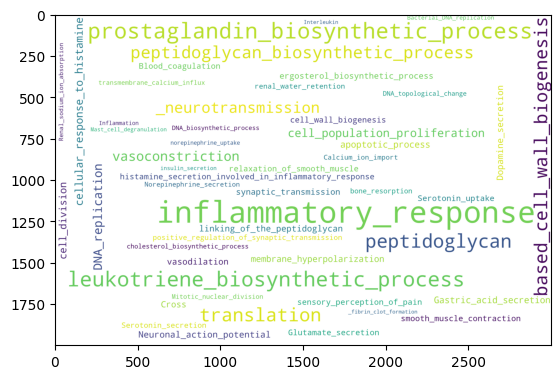

In [112]:
plt.figure( dpi=100)
word_cloud = WordCloud(
width = 3000,
height= 2000, 
random_state= 1,
background_color= "white",
max_words=50,
collocations= False,
stopwords= STOPWORDS).generate(text_bp)
plt.imshow(word_cloud)


wordcloud_svg = word_cloud.to_svg(embed_font=True)
# f = open("BP_WC.svg","w+")
# f.write(wordcloud_svg )
# f.close()

In [113]:
#Join concept 
list_concept = []
for i in  metanode_node["Protein"]:
    split_concept = i.split(" ")
    join_concept = "_".join(i for i in split_concept)
    list_concept.append(join_concept)

In [114]:
text_protein = " ".join(cat for cat in list_concept)

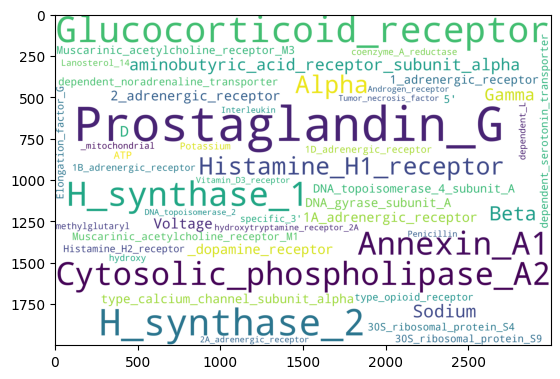

In [115]:
plt.figure( dpi=100)
word_cloud = WordCloud(
width = 3000,
height= 2000, 
random_state= 1,
background_color= "white",
max_words=50,
collocations= False,
stopwords= STOPWORDS).generate(text_protein)
plt.imshow(word_cloud)


wordcloud_svg = word_cloud.to_svg(embed_font=True)
# f = open("Protein.svg","w+")
# f.write(wordcloud_svg )
# f.close()

In [116]:
#Join concept 
list_concept = []
for i in  metanode_node["Disease"]:
    split_concept = i.split(" ")
    join_concept = "_".join(i for i in split_concept)
    list_concept.append(join_concept)

In [117]:
text_dis = " ".join(cat for cat in list_concept)

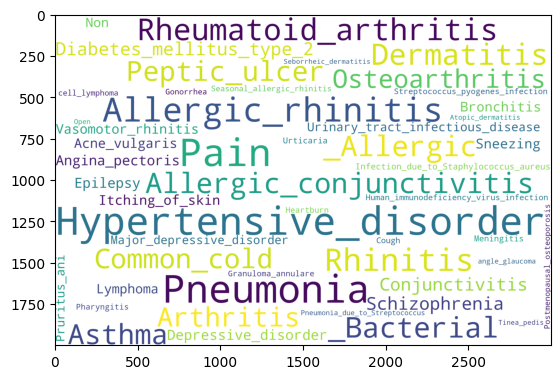

In [118]:
plt.figure( dpi=100)
word_cloud = WordCloud(
width = 3000,
height= 2000, 
random_state= 1,
background_color= "white",
max_words=50,
collocations= False,
stopwords= STOPWORDS).generate(text_dis)
plt.imshow(word_cloud)


wordcloud_svg = word_cloud.to_svg(embed_font=True)
# f = open("Disease_WC.svg","w+")
# f.write(wordcloud_svg )
# f.close()

In [119]:
#Join concept 
list_concept = []
for i in  metanode_node["Drug"]:
    split_concept = i.split(" ")
    join_concept = "_".join(i for i in split_concept)
    list_concept.append(join_concept)

In [120]:
text_drug = " ".join(cat for cat in list_concept)

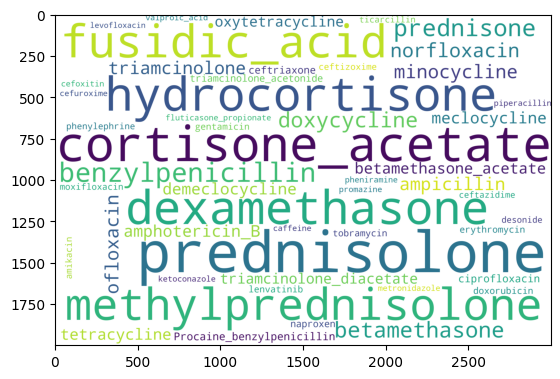

In [121]:
plt.figure( dpi=100)
word_cloud = WordCloud(
width = 3000,
height= 2000, 
random_state= 1,
background_color= "white",
max_words=50,
collocations= False,
stopwords= STOPWORDS).generate(text_drug)
plt.imshow(word_cloud)


wordcloud_svg = word_cloud.to_svg(embed_font=True)
# f = open("Drug_WC.svg","w+")
# f.write(wordcloud_svg )
# f.close()

## Figure 3: DrugMechDB edge types

A) Concept type associations

In [122]:
pairs  = set()

for val in all_parings:
    val = val.split(" - ")
    pairs.add(val[0])

In [123]:
#all combination of concept type pairs DMDB 
print("Total combination of concept type pairs: ", len(set(all_parings)))

Total combination of concept type pairs:  129


<Figure size 640x480 with 0 Axes>

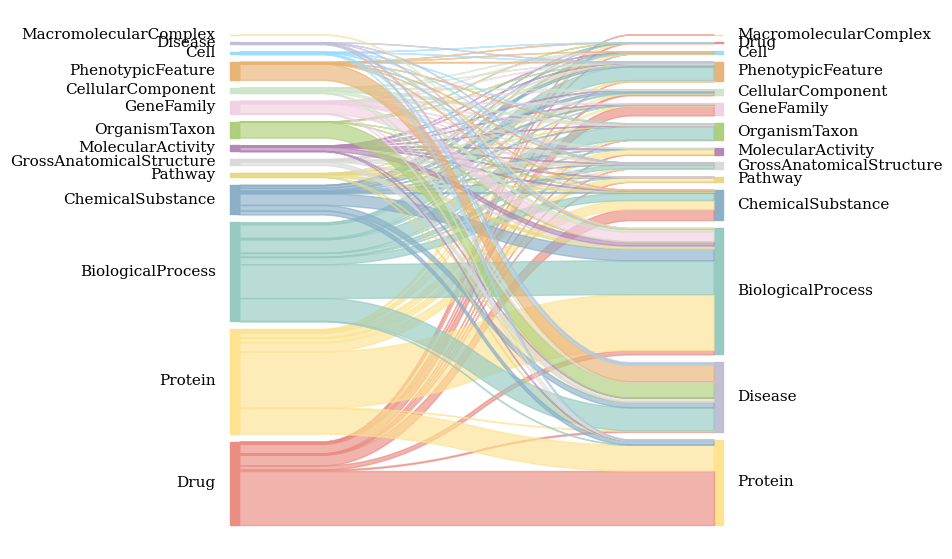

In [124]:
#Sankey diagram 
colorDict = {'BiologicalProcess': "#96CAC1",
 'Cell': "#99DDFE" ,
 'CellularComponent': "#CEE5CA",
 'ChemicalSubstance': "#8AAFC8",
 'Disease': "#C0BED6",
 'Drug': "#EA8D82",
 'GeneFamily': "#F0D0E1",
 'GrossAnatomicalStructure': "#D9D9D9",
 'MacromolecularComplex': "#F8DF9D",
 'MolecularActivity': "#B588B5",
 'OrganismTaxon': "#AECF78",
 'Pathway': "#E5D986",
 'PhenotypicFeature': "#E9B375",
 'Protein': "#FDE391"}

plt.figure(dpi=100)
source =[]
target =[]

for val in all_parings:
    val = val.split(" - ")
    source.append(val[0])
    target.append(val[1])
sankey(source,
       target, 
       aspect=15, 
       fontsize=11, 
      colorDict=colorDict)
# Get current figure
fig = plt.gcf()


# Set size in inches
fig.set_size_inches(7, 7)

# Set the color of the background to white
fig.set_facecolor("w")

# Save the figure
#fig.savefig("DMDB_relations_sankey.pdf", bbox_inches="tight", dpi=1000)

In [125]:
#Count % of most frequent metapair
total_pairs = (all_parings)
print("Total concept type pairs: ", len(total_pairs))


most_frequent_pair = len([i for i in all_parings if i == 'Protein - BiologicalProcess'])
print("Most frequent pair: ('Protein - BiologicalProcess') ", most_frequent_pair)

print("% most frequent pair ('Protein - BiologicalProcess'): ", (most_frequent_pair*100)/len(total_pairs))

Total concept type pairs:  32597
Most frequent pair: ('Protein - BiologicalProcess')  4699
% most frequent pair ('Protein - BiologicalProcess'):  14.415437003405222


B) Most common meta-edges

KeyError: ''

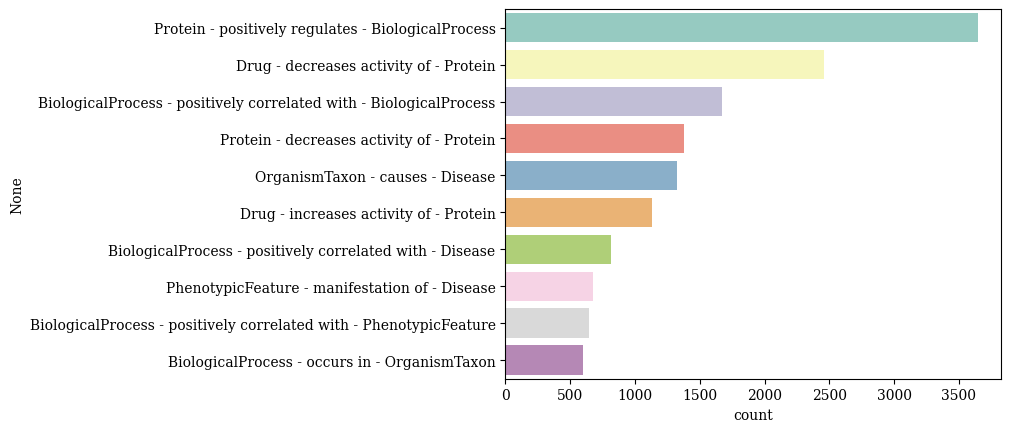

In [128]:
plt.figure(dpi=100)

# Filter out empty strings or missing values
filtered_metaedges = [edge for edge in all_metaedges if edge and edge.strip()]

me_counts = pd.Series(filtered_metaedges).value_counts()
count_plot_h(me_counts.head(10))
font = {'family': 'sans'}
plt.rc('font', **font)

plt.grid(linewidth=0.1)
plt.ylabel('Metaedges')
plt.xlim(0,4000)

font = {'family': 'sans'}
plt.rc('font', **font)

plt.title('Most common metaedges in DrugMechDB')
plt.xlabel('Number of times metaedge appears');
#plt.savefig('Most common metaedges in DrugMechDB.pdf')

In [129]:
#Meta-edges (Source-relation-Target)
print("Number of unique meta-edges: ", len(set(all_metaedges)))

Number of unique meta-edges:  726


In [130]:
#Calculate percentage of most common metaedge 
total_metaedges = (all_metaedges)
most_common_me = len([i for i in total_metaedges if i =='Protein - positively regulates - BiologicalProcess'])

print("Most common meta-edge('Protein - positively regulates - BiologicalProcess'): ", 
      most_common_me, 
      f"({(most_common_me*100)/len(all_metaedges)}%)")

Most common meta-edge('Protein - positively regulates - BiologicalProcess'):  3644 (11.178942847501304%)


C) Distribution of edges per indication 

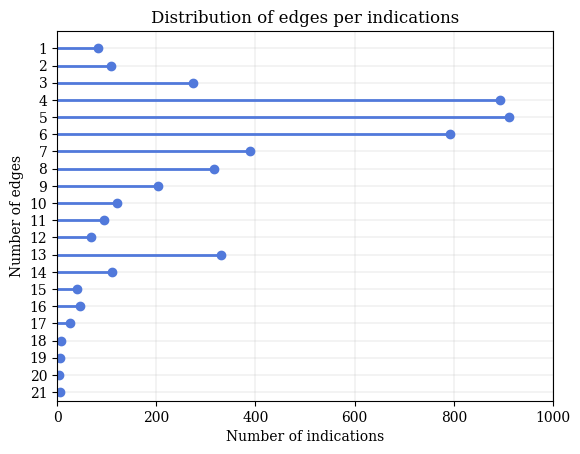

In [131]:
heads, locs = np.histogram(basic_stats['n_edges'], bins= 31)
plt.figure( dpi=100)
(markers, stemlines, baseline) =  plt.stem([str(i) for i in range(1,32)],
         heads, 
         basefmt = " ",
        orientation = "horizontal", )

plt.setp(stemlines, linestyle="-", color= '#5179DB', linewidth= 2 )
plt.setp(markers,  color='#5179DB')
plt.xlim([0,1000])
plt.ylim([-1,20.5])

plt.grid(linewidth=0.2)
plt.gca().invert_yaxis()
plt.title('Distribution of edges per indications')
plt.ylabel('Number of edges')
plt.xlabel('Number of indications');

# plt.savefig('Distribution of edges per indication.pdf')

## Figure 4: DrugMechDB mechanistic paths

A) Most common mechanistic paths (excluding edges)

In [173]:
type(all_metapath_nodes)
# print few lines of metapath_node
{k: all_metapath_nodes[k] for k in list(all_metapath_nodes)[:5]}

{'DB00619_MESH_D015464_1': ['Drug - Protein - Disease'],
 'DB00619_MESH_D034721_1': ['Drug - Protein - BiologicalProcess - Disease'],
 'DB00316_MESH_D010146_1': ['Drug - Protein - BiologicalProcess - ChemicalSubstance - Disease'],
 'DB00316_MESH_D005334_1': ['Drug - Pathway - GrossAnatomicalStructure - BiologicalProcess - Disease'],
 'DB00945_MESH_D010146_1': ['Drug - Protein - BiologicalProcess - Disease']}

In [175]:
metapaths_df = pd.DataFrame( columns= ["DMDB_ID", "Metapath"])

for id_ in all_metapath_nodes:
    for p in all_metapath_nodes[id_]:
        metapaths_df = pd.concat([metapaths_df, pd.DataFrame({"DMDB_ID": [id_], 
                            "Metapath": [p]})], ignore_index= True)

print("Nmber of unique mechanistic paths (excluding edges): ", len(set(metapaths_df["Metapath"].to_list())))

Nmber of unique mechanistic paths (excluding edges):  298


In [177]:
metapath_data = [
    {"DMDB_ID": id_, "Metapath": p}
    for id_ in all_metapath_nodes
    for p in all_metapath_nodes[id_]
]

# Convert accumulated data into a DataFrame
metapaths_df = pd.DataFrame(metapath_data)

# Print the number of unique mechanistic paths (excluding edges)
unique_metapaths = metapaths_df["Metapath"].nunique()
print("Number of unique mechanistic paths (excluding edges):", unique_metapaths)

Number of unique mechanistic paths (excluding edges): 298


In [178]:
metapaths_df.head()

,DMDB_ID,Metapath
0,DB00619_MESH_D015464_1,Drug - Protein - Disease
1,DB00619_MESH_D034721_1,Drug - Protein - BiologicalProcess - Disease
2,DB00316_MESH_D010146_1,Drug - Protein - BiologicalProcess - ChemicalSubstance - Disease
3,DB00316_MESH_D005334_1,Drug - Pathway - GrossAnatomicalStructure - BiologicalProcess - Disease
4,DB00945_MESH_D010146_1,Drug - Protein - BiologicalProcess - Disease


KeyError: ''

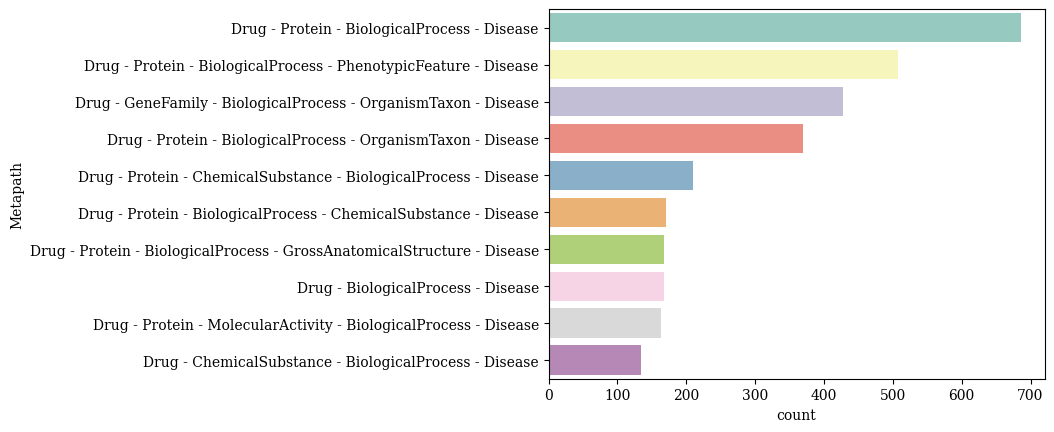

In [176]:
plt.figure( dpi=100)
me_counts = pd.Series(metapaths_df["Metapath"]).value_counts()
count_plot_h(me_counts.head(10))

plt.grid(linewidth=0.1)
plt.ylabel('');
plt.title('Most common Metapaths in DrugMechDB')
plt.xlabel('Count');

# plt.savefig('Most common Metapaths in DrugMechDB.pdf')

In [136]:
metapaths_df.head(2)

,DMDB_ID,Metapath
0,DB00619_MESH_D015464_1,Drug - Protein - Disease
1,DB00619_MESH_D034721_1,Drug - Protein - BiologicalProcess - Disease


In [149]:
type(all_metapath_nodes)

collections.defaultdict

In [152]:
all_metapath_nodes.items()

dict_items([('DB00619_MESH_D015464_1', ['Drug - Protein - Disease']), ('DB00619_MESH_D034721_1', ['Drug - Protein - BiologicalProcess - Disease']), ('DB00316_MESH_D010146_1', ['Drug - Protein - BiologicalProcess - ChemicalSubstance - Disease']), ('DB00316_MESH_D005334_1', ['Drug - Pathway - GrossAnatomicalStructure - BiologicalProcess - Disease']), ('DB00945_MESH_D010146_1', ['Drug - Protein - BiologicalProcess - Disease']), ('DB00945_MESH_D013927_1', ['Drug - Protein - Pathway - ChemicalSubstance - BiologicalProcess - Disease', 'Drug - Protein - BiologicalProcess - Disease']), ('DB00788_MESH_D010146_1', ['Drug - Protein - ChemicalSubstance - BiologicalProcess - Disease']), ('DB01059_MESH_D004405_1', ['Drug - Protein - BiologicalProcess - OrganismTaxon - Disease', 'Drug - MolecularActivity - BiologicalProcess - OrganismTaxon - Disease']), ('DB01380_MESH_D007634_1', ['Drug - Protein - ChemicalSubstance - BiologicalProcess - Disease', 'Drug - Protein - BiologicalProcess - Disease', 'Drug

In [153]:
#Number of metapaths
mp_nodes = []
for id_ in all_metapath_nodes:
    for p in all_metapath_nodes[id_]:
        mp_nodes.append(p)


total_mp_nodes = len(((mp_nodes)))
most_common_mp = len([i for i in mp_nodes if i == "Drug - Protein - BiologicalProcess - Disease"])


print("Most common meta-path(Drug - Protein - BiologicalProcess - Disease): ", most_common_mp, 
      f"({(most_common_mp*100)/total_mp_nodes}%)")

Most common meta-path(Drug - Protein - BiologicalProcess - Disease):  686 (12.16959375554373%)


In [155]:
basic_stats[basic_stats['metapath'].apply(lambda x: 'Drug - Protein - BiologicalProcess - Disease' in x)].shape


(686, 10)

In [156]:
basic_stats[basic_stats['metapath'].apply(lambda x: 'Drug - Protein - BiologicalProcess - Disease' in x)].head(6)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
1,1,DB00619_MESH_D034721_1,DB:DB00619,MESH:D034721,"(MESH:D000068877, UniProt:P10721, UniProt:P16234, GO:0008283, MESH:D034721)",5,5,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease]
4,4,DB00945_MESH_D010146_1,DB:DB00945,MESH:D010146,"(MESH:D001241, UniProt:P23219, UniProt:P35354, GO:0001516, MESH:D011453, GO:0006954, MESH:D010146)",7,7,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease]
5,5,DB00945_MESH_D013927_1,DB:DB00945,MESH:D013927,"(MESH:D001241, UniProt:P23219, reactome:R-HSA-2162123, MESH:D013928, GO:0007596, MESH:D013927)",6,6,2,"[Drug - Protein - Pathway - ChemicalSubstance - BiologicalProcess - Disease, Drug - Protein - BiologicalProcess - Disease]","[Drug - decreases activity of - Protein - participates in - Pathway - has output - ChemicalSubstance - participates in - BiologicalProcess - causes - Disease, Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease]"
8,8,DB01380_MESH_D007634_1,DB:DB01380,MESH:D007634,"(MESH:D003348, UniProt:P04150, UniProt:P23219, UniProt:P04083, reactome:R-HSA-2162123, MESH:D011453, GO:0050900, GO:0006954, MESH:D007634)",9,13,3,"[Drug - Protein - ChemicalSubstance - BiologicalProcess - Disease, Drug - Protein - BiologicalProcess - Disease, Drug - Protein - Pathway - BiologicalProcess - Disease]","[Drug - decreases abundance of - Protein - increases abundance of - ChemicalSubstance - participates in - BiologicalProcess - causes - Disease, Drug - decreases abundance of - Protein - negatively regulates - BiologicalProcess - causes - Disease, Drug - decreases abundance of - Protein - negatively regulates - Pathway - positively regulates - BiologicalProcess - causes - Disease]"
17,17,DB06762_MESH_D006973_1,DB:DB06762,MESH:D006973,"(MESH:D020110, UniProt:Q12791, GO:0042311, GO:0008217, MESH:D006973)",5,4,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - increases activity of - Protein - participates in - BiologicalProcess - prevents - Disease]
19,19,DB08799_MESH_D012223_1,DB:DB08799,MESH:D012223,"(MESH:D000865, UniProt:P35367, GO:0034776, MESH:D012223)",4,3,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease]


In [122]:
df = basic_stats[basic_stats['metapath'].apply(lambda x: 'Drug - Protein - BiologicalProcess - Disease' in x)]
df[df['n_nodes'] == 4].shape

(85, 10)

In [123]:
df[df['n_nodes'] == 4].head(5)


,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
19,19,DB08799_MESH_D012223_1,DB:DB08799,MESH:D012223,"(MESH:D000865, UniProt:P35367, GO:0034776, MESH:D012223)",4,3,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease]
30,30,DB00748_MESH_D003233_1,DB:DB00748,MESH:D003233,"(MESH:C004649, UniProt:P35367, GO:0034776, MESH:D003233)",4,3,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - causes - Disease]
31,31,DB00066_MESH_D016649_1,DB:DB00066,MESH:D016649,"(MESH:D005640, UniProt:P23945, GO:0030728, MESH:D016649)",4,3,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - increases activity of - Protein - positively regulates - BiologicalProcess - negatively correlated with - Disease]
35,35,DB09046_MESH_D008060_1,DB:DB09046,MESH:D008060,"(MESH:C415771, UniProt:P48357, GO:0060612, MESH:D008060)",4,3,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - increases activity of - Protein - regulates - BiologicalProcess - negatively correlated with - Disease]
37,37,DB00455_MESH_D065631_1,DB:DB00455,MESH:D065631,"(MESH:D017336, UniProt:P35367, GO:0034776, MESH:D065631)",4,3,1,[Drug - Protein - BiologicalProcess - Disease],[Drug - decreases activity of - Protein - participates in - BiologicalProcess - causes - Disease]


In [119]:
def contains_target_string(metapath_with_edges_list, target_string):
    return target_string in metapath_with_edges_list

target_string = "Drug - decreases activity of - Protein - causes - Disease"

filtered_df = basic_stats[basic_stats['metapath_with_edges'].apply(lambda x: contains_target_string(x, target_string))]

In [121]:
filtered_df

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges
0,0,DB00619_MESH_D015464_1,DB:DB00619,MESH:D015464,"(MESH:D000068877, UniProt:P00519, MESH:D015464)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
241,241,DB04865_MESH_D015464_1,DB:DB04865,MESH:D015464,"(MESH:C001652, UniProt:P39023, GO:0006412, UniProt:A9UF02, MESH:D015464)",5,4,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]
435,435,DB06616_MESH_D001752_1,DB:DB06616,MESH:D001752,"(MESH:C471992, UniProt:A9UF02, MESH:D001752)",3,2,1,[Drug - Protein - Disease],[Drug - decreases activity of - Protein - causes - Disease]


B) Most common mechanistic paths (including edges)


In [108]:
mp_edges = []
for id_ in all_metapath_edges:
    for p in all_metapath_edges[id_]:
        mp_edges.append(p)

print("Number of mechanistic paths (including edges): ",(len(set(mp_edges))))

Number of mechanistic paths (including edges):  1458


In [110]:
metapaths_edge_df = [
    {"DMDB_ID": id_, "Metapath_edge": p}
    for id_ in all_metapath_edges
    for p in all_metapath_edges[id_]
]



Text(0.5, 0, 'Count')

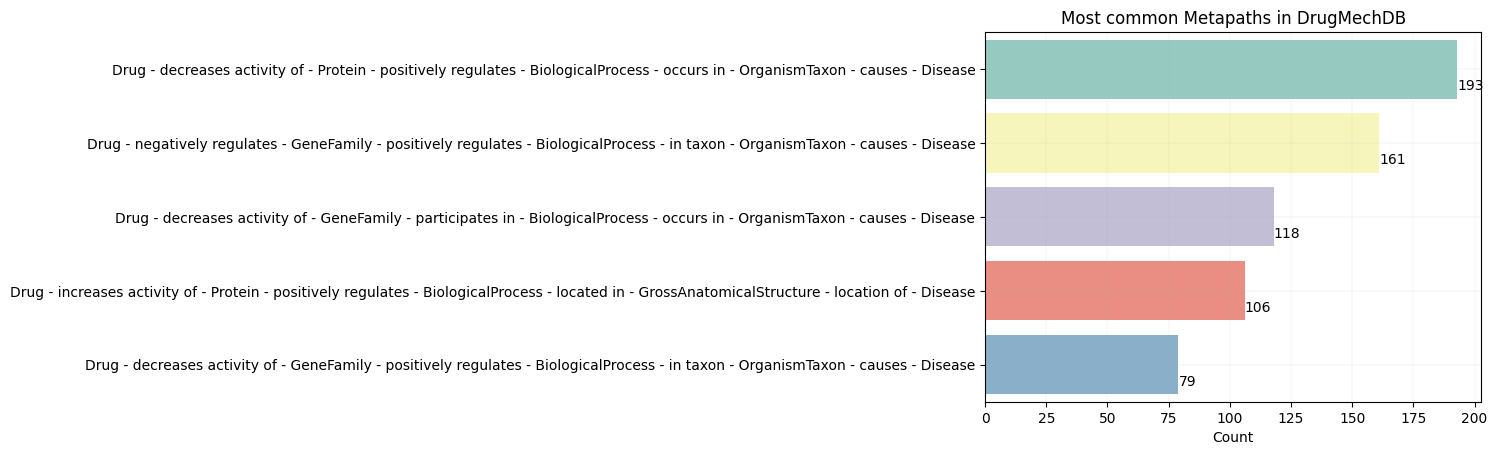

In [112]:
# Convert the list of dictionaries to a DataFrame
metapaths_edge_df = pd.DataFrame(metapaths_edge_df)

plt.figure(dpi=100)
me_counts = pd.Series(metapaths_edge_df["Metapath_edge"]).value_counts()
count_plot_h(me_counts.head(5))

plt.grid(linewidth=0.1)
plt.ylabel('')
plt.title('Most common Metapaths in DrugMechDB')
plt.xlabel('Count')

# plt.savefig('Most common Metapaths in DrugMechDB_B.pdf')

In [64]:
#number of meta_paths (with edges)
total_mp_edges = len((mp_edges))
most_common_mp_edge = len([i for i in mp_edges if i == "Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease"])

print("Most common meta-path(Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease): ", most_common_mp_edge, 
      f"({(most_common_mp_edge*100)/total_mp_edges}%)")



Most common meta-path(Drug - decreases activity of - Protein - positively regulates - BiologicalProcess - occurs in - OrganismTaxon - causes - Disease):  193 (3.467481135465325%)


C) Distribution of paths per indication

Text(0.5, 0, 'Number of indications')

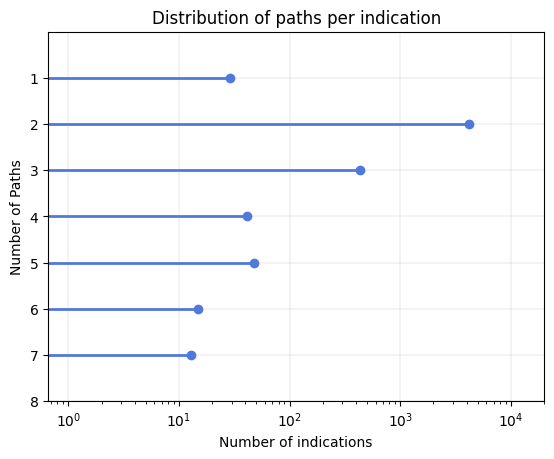

In [65]:
heads, locs = np.histogram(basic_stats['n_paths'], bins= 21)
plt.figure( dpi=100)
(markers, stemlines, baseline) =  plt.stem([str(i) for i in range(1,22)],
         heads, 
         basefmt = " ",
        orientation = "horizontal", )

plt.setp(stemlines, linestyle="-", color= '#5179DB', linewidth= 2 )
plt.setp(markers,  color='#5179DB')
plt.xscale("log")

plt.ylim([-1,7])
plt.xlim([0,20000])

plt.grid(linewidth=0.2)
plt.gca().invert_yaxis()
plt.title('Distribution of paths per indication')
plt.ylabel('Number of Paths')
plt.xlabel('Number of indications')


#plt.savefig('Distribution of paths per indication.pdf')

### Table 1

In [66]:
#outgoing edges

node_me = defaultdict(list)
node_me_unique = defaultdict(set)

for mp in all_metaedges:
    mp = mp.split(" - ")
    node_me[mp[0]].append(mp[1])
    node_me_unique[mp[0]].add(mp[1])

In [67]:
#Edge count by concept type
sum_node_me = 0
for k,v in node_me.items():
    sum_node_me += len(v)
    print(k, len(v))

print(sum_node_me)

Drug 6886
Protein 8704
BiologicalProcess 8235
ChemicalSubstance 2474
Pathway 348
GrossAnatomicalStructure 534
MolecularActivity 474
OrganismTaxon 1343
GeneFamily 958
CellularComponent 456
PhenotypicFeature 1499
Cell 186
Disease 147
MacromolecularComplex 5
32249


In [68]:
#Unique Edge-types by concept type
sum_node_me = 0
for k,v in node_me_unique.items():
    sum_node_me += len(v)
    print(k, len(v))

print(sum_node_me)

Drug 38
Protein 33
BiologicalProcess 38
ChemicalSubstance 35
Pathway 20
GrossAnatomicalStructure 24
MolecularActivity 21
OrganismTaxon 5
GeneFamily 21
CellularComponent 15
PhenotypicFeature 17
Cell 19
Disease 12
MacromolecularComplex 1
299
